In [1]:
import pandas as pd
import numpy as np

# ============================================================
# LOAD (si ya lo cargaste antes, puedes saltar esto)
# ============================================================

rep_file = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/louvain_by_level_from_table_including_isolates/representatives_by_cluster_level.tsv"
typing_file = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/cell_level/meta/typing.csv"

rep = pd.read_csv(rep_file, sep="\t")
typing = pd.read_csv(typing_file)

typing_rep = typing[typing["NUCCORE_ACC"].isin(rep["representative"])].copy()

typing_rep["rep_count_class"] = np.where(
    typing_rep["rep_type(s)"].str.contains(",", na=False),
    "multi_rep",
    "single_rep"
)

# ============================================================
# DISTRIBUTION
# ============================================================

dist = (
    typing_rep
    .groupby(["predicted_mobility", "rep_count_class"])
    .size()
    .unstack(fill_value=0)
    .sort_values(by="multi_rep", ascending=False)
)

display(dist)

# Normalized (row-wise)
display(dist.div(dist.sum(axis=1), axis=0))


rep_count_class,multi_rep,single_rep
predicted_mobility,,
conjugative,4121,4255
mobilizable,1884,5510
non-mobilizable,1544,6611


rep_count_class,multi_rep,single_rep
predicted_mobility,,
conjugative,0.492001,0.507999
mobilizable,0.254801,0.745199
non-mobilizable,0.189332,0.810668


In [2]:
from scipy.stats import fisher_exact

results = []

for cat in typing_rep["predicted_mobility"].dropna().unique():
    
    sub = typing_rep.copy()
    sub["is_cat"] = sub["predicted_mobility"] == cat
    
    ct = pd.crosstab(sub["is_cat"], sub["rep_count_class"])
    
    # Ensure all cells exist
    for col in ["single_rep", "multi_rep"]:
        if col not in ct.columns:
            ct[col] = 0
    for row in [True, False]:
        if row not in ct.index:
            ct.loc[row] = [0, 0]
    
    table = [
        [ct.loc[True,  "single_rep"], ct.loc[True,  "multi_rep"]],
        [ct.loc[False, "single_rep"], ct.loc[False, "multi_rep"]],
    ]
    
    or_val, p_val = fisher_exact(table)
    
    results.append({
        "predicted_mobility": cat,
        "odds_ratio_multi_vs_single": or_val,
        "p_value": p_val,
        "n_cat": ct.loc[True].sum()
    })

res_df = (
    pd.DataFrame(results)
    .sort_values("odds_ratio_multi_vs_single", ascending=False)
)

display(res_df)


,predicted_mobility,odds_ratio_multi_vs_single,p_value,n_cat
0,non-mobilizable,2.633059,6.323593e-211,8155
1,mobilizable,1.524758,1.793045e-42,7394
2,conjugative,0.292011,0.000000e+00,8376


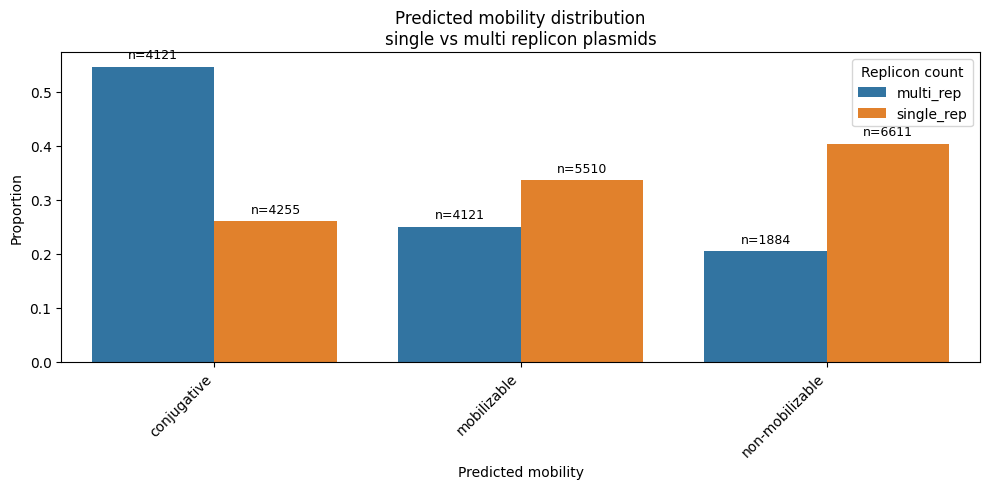

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# PREP DATA
# ============================================================

prop_df = (
    typing_rep
    .groupby(["rep_count_class", "predicted_mobility"])
    .size()
    .reset_index(name="count")
)

prop_df["prop"] = prop_df.groupby("rep_count_class")["count"].transform(
    lambda x: x / x.sum()
)

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=prop_df,
    x="predicted_mobility",
    y="prop",
    hue="rep_count_class"
)

# ============================================================
# ADD Ns
# ============================================================

for container, rep_class in zip(ax.containers, prop_df["rep_count_class"].unique()):
    for bar in container:
        height = bar.get_height()
        if height > 0:
            # find corresponding count
            x = bar.get_x() + bar.get_width() / 2
            idx = (
                (prop_df["rep_count_class"] == rep_class) &
                (prop_df["predicted_mobility"] == ax.get_xticklabels()[int(x)].get_text())
            )
            n = prop_df.loc[idx, "count"].values
            if len(n) > 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    height + 0.01,
                    f"n={int(n[0])}",
                    ha="center",
                    va="bottom",
                    fontsize=9
                )

# ============================================================
# FINAL TOUCHES
# ============================================================

ax.set_ylabel("Proportion")
ax.set_xlabel("Predicted mobility")
ax.set_title("Predicted mobility distribution\nsingle vs multi replicon plasmids")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Replicon count")

plt.tight_layout()
plt.show()


In [7]:
# ============================================================
# SUMMARY TABLE + EXPORT
# ============================================================

summary_table = (
    typing_rep
    .groupby(["rep_count_class", "predicted_mobility"])
    .size()
    .reset_index(name="count")
)

summary_table["prop"] = summary_table.groupby("rep_count_class")["count"].transform(
    lambda x: x / x.sum()
)

# Export
out_path = "predicted_mobility_summary_table.tsv"
summary_table.to_csv(out_path, sep="\t", index=False)

summary_table


,rep_count_class,predicted_mobility,count,prop
0,multi_rep,conjugative,4121,0.545900
1,multi_rep,mobilizable,1884,0.249569
2,multi_rep,non-mobilizable,1544,0.204530
3,single_rep,conjugative,4255,0.259831
4,single_rep,mobilizable,5510,0.336468
5,single_rep,non-mobilizable,6611,0.403701


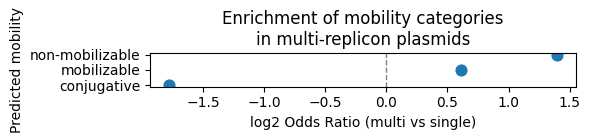

In [4]:
import numpy as np

# ============================================================
# CLEAN + ORDER
# ============================================================

plot_df = res_df.copy()

plot_df["log2_OR"] = np.log2(plot_df["odds_ratio_multi_vs_single"])
plot_df = plot_df.sort_values("log2_OR")

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(6, 0.5 * len(plot_df)))

plt.axvline(0, color="grey", linestyle="--", linewidth=1)

plt.scatter(
    plot_df["log2_OR"],
    plot_df["predicted_mobility"],
    s=60
)

plt.xlabel("log2 Odds Ratio (multi vs single)")
plt.ylabel("Predicted mobility")
plt.title("Enrichment of mobility categories\nin multi-replicon plasmids")

plt.tight_layout()
plt.show()


In [6]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, fisher_exact

# ============================================================
# 1. LOAD DATA
# ============================================================

rep_file = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/louvain_by_level_from_table_including_isolates/representatives_by_cluster_level.tsv"
typing_file = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/cell_level/meta/typing.csv"

rep = pd.read_csv(rep_file, sep="\t")
typing = pd.read_csv(typing_file)

# ============================================================
# 2. FILTER TO REPRESENTATIVE PLASMIDS
# ============================================================

df = typing[typing["NUCCORE_ACC"].isin(rep["representative"])].copy()

df["rep_count_class"] = np.where(
    df["rep_type(s)"].str.contains(",", na=False),
    "multi_rep",
    "single_rep"
)

# ============================================================
# 3. DESCRIPTIVE STATS (PERCENTAGES)
# ============================================================

desc = (
    df
    .groupby(["rep_count_class", "predicted_mobility"])
    .size()
    .reset_index(name="n")
)

desc["percent"] = desc.groupby("rep_count_class")["n"].transform(
    lambda x: 100 * x / x.sum()
)

print("\n=== Percentages ===")
display(desc.sort_values(["rep_count_class", "percent"], ascending=[True, False]))

# ============================================================
# 4. GLOBAL TEST: χ² INDEPENDENCE
# ============================================================

ct_global = pd.crosstab(df["predicted_mobility"], df["rep_count_class"])
chi2, p_chi2, dof, _ = chi2_contingency(ct_global)

print("\n=== Global chi-square test ===")
print(f"chi2 = {chi2:.2f}, dof = {dof}, p = {p_chi2:.2e}")

# ============================================================
# 5. CATEGORY-SPECIFIC TESTS: FISHER + ODDS RATIO
# ============================================================

results = []

for cat in df["predicted_mobility"].dropna().unique():
    
    tmp = df.copy()
    tmp["is_cat"] = tmp["predicted_mobility"] == cat
    
    ct = pd.crosstab(tmp["is_cat"], tmp["rep_count_class"])
    
    # ensure full table
    for col in ["single_rep", "multi_rep"]:
        if col not in ct.columns:
            ct[col] = 0
    for row in [True, False]:
        if row not in ct.index:
            ct.loc[row] = [0, 0]
    
    a = ct.loc[True,  "single_rep"]
    b = ct.loc[True,  "multi_rep"]
    c = ct.loc[False, "single_rep"]
    d = ct.loc[False, "multi_rep"]
    
    or_val, p_val = fisher_exact([[a, b], [c, d]])
    
    results.append({
        "predicted_mobility": cat,
        "OR_multi_vs_single": or_val,
        "p_value": p_val,
        "n_cat": a + b,
        "pct_single": 100 * a / (a + c) if (a + c) > 0 else np.nan,
        "pct_multi": 100 * b / (b + d) if (b + d) > 0 else np.nan
    })

res_df = (
    pd.DataFrame(results)
    .sort_values("OR_multi_vs_single", ascending=False)
)

print("\n=== Category-specific enrichment (one-vs-rest) ===")
display(res_df)



=== Percentages ===


,rep_count_class,predicted_mobility,n,percent
0,multi_rep,conjugative,4121,54.590012
1,multi_rep,mobilizable,1884,24.956948
2,multi_rep,non-mobilizable,1544,20.453040
5,single_rep,non-mobilizable,6611,40.370054
4,single_rep,mobilizable,5510,33.646800
3,single_rep,conjugative,4255,25.983146



=== Global chi-square test ===
chi2 = 1935.41, dof = 2, p = 0.00e+00

=== Category-specific enrichment (one-vs-rest) ===


,predicted_mobility,OR_multi_vs_single,p_value,n_cat,pct_single,pct_multi
0,non-mobilizable,2.633059,6.323593e-211,8155,40.370054,20.453040
1,mobilizable,1.524758,1.793045e-42,7394,33.646800,24.956948
2,conjugative,0.292011,0.000000e+00,8376,25.983146,54.590012



=== Counts and percentages (within replicon class) ===
  rep_count_class predicted_mobility     n    percent
0       multi_rep        conjugative  4121  54.590012
1       multi_rep        mobilizable  1884  24.956948
2       multi_rep    non-mobilizable  1544  20.453040
5      single_rep    non-mobilizable  6611  40.370054
4      single_rep        mobilizable  5510  33.646800
3      single_rep        conjugative  4255  25.983146

=== Totals ===
rep_count_class
single_rep    16376
multi_rep      7549
Name: count, dtype: int64

=== Global chi-square test ===
chi2 = 1935.41
dof = 2
p-value = 0.000e+00

=== Category-specific enrichment (Fisher one-vs-rest) ===
  predicted_mobility  OR_multi_vs_single      interpretation        p_value  \
2        conjugative            3.424528   enriched_in_multi   0.000000e+00   
1        mobilizable            0.655842  enriched_in_single   1.793045e-42   
0    non-mobilizable            0.379786  enriched_in_single  6.323593e-211   

   n_total_in_cat

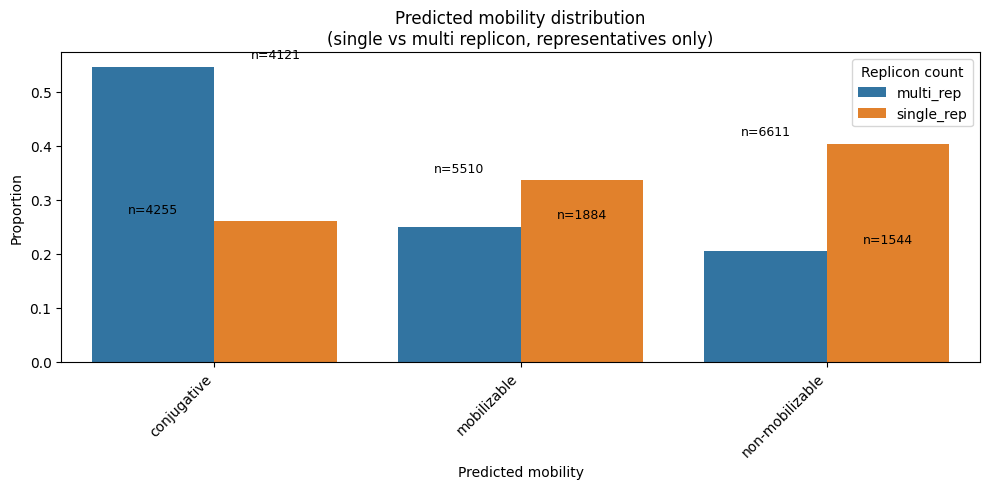

In [9]:
# ============================================================
# Mobility vs replicon count (representatives only)
# Single chunk: plot + Ns + percentages + statistics
# ============================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, fisher_exact

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------

rep_file = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/louvain_by_level_from_table_including_isolates/representatives_by_cluster_level.tsv"
typing_file = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/cell_level/meta/typing.csv"

rep = pd.read_csv(rep_file, sep="\t")
typing = pd.read_csv(typing_file)

# ------------------------------------------------------------
# 2. FILTER TO REPRESENTATIVE PLASMIDS
# ------------------------------------------------------------

df = typing[typing["NUCCORE_ACC"].isin(rep["representative"])].copy()

df["rep_count_class"] = np.where(
    df["rep_type(s)"].str.contains(",", na=False),
    "multi_rep",
    "single_rep"
)

# ------------------------------------------------------------
# 3. DESCRIPTIVE TABLE
# ------------------------------------------------------------

desc = (
    df
    .groupby(["rep_count_class", "predicted_mobility"])
    .size()
    .reset_index(name="n")
)

desc["percent"] = desc.groupby("rep_count_class")["n"].transform(
    lambda x: 100 * x / x.sum()
)

print("\n=== Counts and percentages (within replicon class) ===")
print(desc.sort_values(["rep_count_class", "percent"], ascending=[True, False]))

# Totals per class
totals = df["rep_count_class"].value_counts()
print("\n=== Totals ===")
print(totals)

# ------------------------------------------------------------
# 4. GLOBAL CHI-SQUARE TEST
# ------------------------------------------------------------

ct_global = pd.crosstab(df["predicted_mobility"], df["rep_count_class"])
chi2, p_chi2, dof, exp = chi2_contingency(ct_global)

print("\n=== Global chi-square test ===")
print(f"chi2 = {chi2:.2f}")
print(f"dof = {dof}")
print(f"p-value = {p_chi2:.3e}")

# ------------------------------------------------------------
# 5. CATEGORY-SPECIFIC FISHER TESTS (multi vs single)
# ------------------------------------------------------------

results = []

for cat in df["predicted_mobility"].dropna().unique():
    
    tmp = df.copy()
    tmp["is_cat"] = tmp["predicted_mobility"] == cat
    
    ct = pd.crosstab(tmp["is_cat"], tmp["rep_count_class"])
    
    for col in ["single_rep", "multi_rep"]:
        if col not in ct.columns:
            ct[col] = 0
    for row in [True, False]:
        if row not in ct.index:
            ct.loc[row] = [0, 0]
    
    a = ct.loc[True,  "single_rep"]
    b = ct.loc[True,  "multi_rep"]
    c = ct.loc[False, "single_rep"]
    d = ct.loc[False, "multi_rep"]
    
    # OR = odds in multi / odds in single
    or_val, p_val = fisher_exact([[b, a], [d, c]])
    
    results.append({
        "predicted_mobility": cat,
        "OR_multi_vs_single": or_val,
        "interpretation": "enriched_in_multi" if or_val > 1 else "enriched_in_single",
        "p_value": p_val,
        "n_total_in_category": a + b,
        "n_single": a,
        "n_multi": b
    })

res_df = pd.DataFrame(results).sort_values("OR_multi_vs_single", ascending=False)

print("\n=== Category-specific enrichment (Fisher one-vs-rest) ===")
print(res_df)


# ------------------------------------------------------------
# 6. PLOT (with correct Ns)
# ------------------------------------------------------------

plot_df = desc.copy()
plot_df["prop"] = plot_df["percent"] / 100

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=plot_df,
    x="predicted_mobility",
    y="prop",
    hue="rep_count_class"
)

# Add Ns directly from plot_df (robust)
for i, row in plot_df.iterrows():
    
    x_positions = list(plot_df["predicted_mobility"].unique())
    x = x_positions.index(row["predicted_mobility"])
    
    hue_offset = -0.2 if row["rep_count_class"] == "single_rep" else 0.2
    
    ax.text(
        x + hue_offset,
        row["prop"] + 0.01,
        f"n={int(row['n'])}",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set_ylabel("Proportion")
ax.set_xlabel("Predicted mobility")
ax.set_title("Predicted mobility distribution\n(single vs multi replicon, representatives only)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Replicon count")

plt.tight_layout()
plt.show()


In [10]:
# ============================================================
# 7. EXPORT SUMMARY TABLE
# ============================================================

# ---- Merge descriptive + Fisher ----
summary_table = desc.merge(
    res_df,
    on="predicted_mobility",
    how="left"
)

summary_table = summary_table[[
    "rep_count_class",
    "predicted_mobility",
    "n",
    "percent",
    "OR_multi_vs_single",
    "interpretation",
    "p_value"
]].sort_values(["predicted_mobility", "rep_count_class"])

print("\n=== Final summary table ===")
print(summary_table)

# ---- Save to CSV ----
out_file = "mobility_vs_replicon_summary.csv"
summary_table.to_csv(out_file, index=False)

print(f"\nSaved to: {out_file}")



=== Final summary table ===
  rep_count_class predicted_mobility     n    percent  OR_multi_vs_single  \
0       multi_rep        conjugative  4121  54.590012            3.424528   
3      single_rep        conjugative  4255  25.983146            3.424528   
1       multi_rep        mobilizable  1884  24.956948            0.655842   
4      single_rep        mobilizable  5510  33.646800            0.655842   
2       multi_rep    non-mobilizable  1544  20.453040            0.379786   
5      single_rep    non-mobilizable  6611  40.370054            0.379786   

       interpretation        p_value  
0   enriched_in_multi   0.000000e+00  
3   enriched_in_multi   0.000000e+00  
1  enriched_in_single   1.793045e-42  
4  enriched_in_single   1.793045e-42  
2  enriched_in_single  6.323593e-211  
5  enriched_in_single  6.323593e-211  

Saved to: mobility_vs_replicon_summary.csv
